#卒業研究2(k-mer&hyp調整)

**importシリーズ**

In [ ]:
pip install japanize-matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
import seaborn as sns
import os
from google.colab import drive

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

import scipy.stats as stats
from itertools import combinations

In [ ]:
# -----------------------------------------------------------------------------
# 1. データの読み込みと前処理
# -----------------------------------------------------------------------------
print("1. データの読み込みと前処理")

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/卒業研究/for_ML_FGO_PG_202512.xlsx'
df = pd.read_excel(file_path, header=1, sheet_name='Selected dataset')

# 整形
# Positive
df_pos = df.iloc[:, [0, 1, 2, 4]].copy()
df_pos.columns = ['chr', 'Start', 'End', 'Sequence']
df_pos['Label'] = 1
df_pos = df_pos.dropna(subset=['Sequence'])

# Negative
df_neg = df.iloc[:, [12, 13, 14, 16]].copy()
df_neg.columns = ['chr', 'Start', 'End', 'Sequence']
df_neg['Label'] = 0
df_neg = df_neg.dropna(subset=['Sequence'])

# 結合
df_ml = pd.concat([df_pos, df_neg], ignore_index=True)
print(f"データセット準備完了: 合計 {len(df_ml)} 件 (Positive: {len(df_pos)}, Negative: {len(df_neg)})")

1. データの読み込みと前処理
データセット準備完了: 合計 673 件 (Positive: 396, Negative: 277)


2. k-mer長とモデル比較
  - k=3, Random Forest: 83.81%
  - k=3, Logistic Regression: 82.46%
  - k=4, Random Forest: 82.46%
  - k=4, Logistic Regression: 81.73%
  - k=5, Random Forest: 82.61%
  - k=5, Logistic Regression: 86.48%
  - k=6, Random Forest: 82.46%
  - k=6, Logistic Regression: 86.78%
  - k=7, Random Forest: 82.02%
  - k=7, Logistic Regression: 85.44%
  - k=8, Random Forest: 82.01%
  - k=8, Logistic Regression: 80.09%


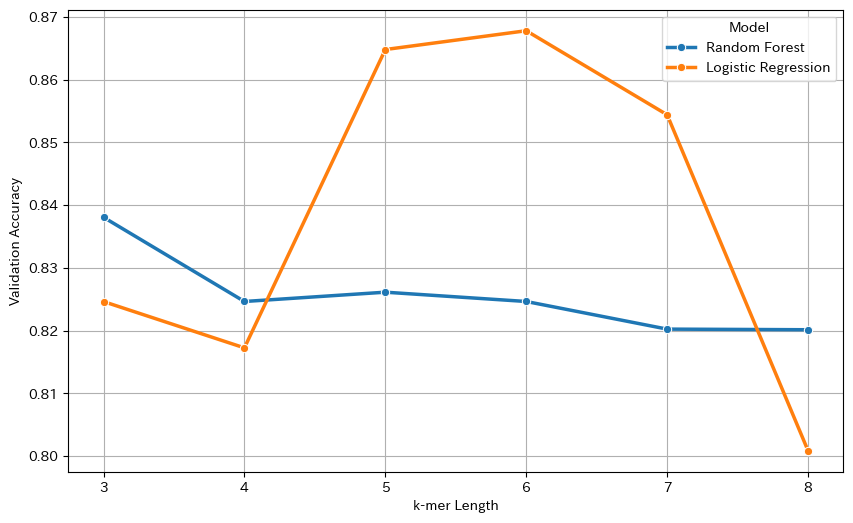


最適設定: k=6, Model=Logistic Regression (Acc: 86.78%)


In [ ]:
# -----------------------------------------------------------------------------
# 2. k-mer長とモデルの比較実験
# -----------------------------------------------------------------------------
print("2. k-mer長とモデル比較")

k_values = [3, 4, 5, 6, 7, 8]
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0)
}

results = []
# Cross Validation
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    cv = CountVectorizer(analyzer='char', ngram_range=(k, k))
    X = cv.fit_transform(df_ml['Sequence'].str.upper())
    y = df_ml['Label']

    for name, model in models.items():
        scores = cross_val_score(model, X, y, cv=cv_strategy, scoring='accuracy')
        mean_acc = scores.mean()
        results.append({'k': k, 'Model': name, 'Accuracy': mean_acc})
        print(f"  - k={k}, {name}: {mean_acc:.2%}")

# 結果の可視化
df_results = pd.DataFrame(results)
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_results, x='k', y='Accuracy', hue='Model', marker='o', linewidth=2.5)
plt.xlabel('k-mer Length')
plt.ylabel('Validation Accuracy')
plt.grid(True)
plt.xticks(k_values)
plt.show()

# 最良の組み合わせの選択
best_result = df_results.loc[df_results['Accuracy'].idxmax()]
best_k = int(best_result['k'])
best_model_name = best_result['Model']
print(f"\n最適設定: k={best_k}, Model={best_model_name} (Acc: {best_result['Accuracy']:.2%})")

In [ ]:
# -----------------------------------------------------------------------------
# 3. 最適設定でのハイパーパラメータ探索
# -----------------------------------------------------------------------------
print(f"3. 最適設定 (k={best_k}) でのハイパーパラメータ探索")

# データを最適kで再作成
cv_best = CountVectorizer(analyzer='char', ngram_range=(best_k, best_k))
X_best = cv_best.fit_transform(df_ml['Sequence'].str.upper())
y_best = df_ml['Label']
feature_names = cv_best.get_feature_names_out()

# 学習用・テスト用に分割
X_train, X_test, y_train, y_test = train_test_split(X_best, y_best, test_size=0.2, random_state=42)

# パラメータ探索範囲の設定
if best_model_name == 'Random Forest':
    estimator = RandomForestClassifier(random_state=42)
    param_grid = {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced', None]
    }
else:
    estimator = LogisticRegression(max_iter=5000, random_state=42)
    param_grid = {
        'C': [0.01, 0.1, 1.0, 10.0],
        'class_weight': ['balanced', None]
    }

# Grid Search
grid_search = GridSearchCV(estimator, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_model_final = grid_search.best_estimator_

print(f"  - Best Parameters: {grid_search.best_params_}")
print(f"  - Final Test Accuracy: {accuracy_score(y_test, best_model_final.predict(X_test)):.2%}")

3. 最適設定 (k=6) でのハイパーパラメータ探索
Fitting 5 folds for each of 8 candidates, totalling 40 fits
  - Best Parameters: {'C': 0.01, 'class_weight': 'balanced'}
  - Final Test Accuracy: 83.70%


4. 図表の作成


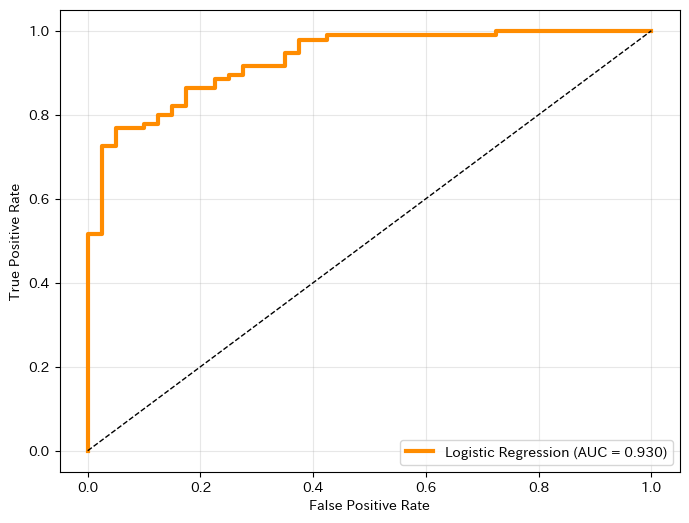


Positive Top 15
 k-mer    Score
ggtcac 0.077765
gggtca 0.060899
ggcatc 0.057655
ctgctg 0.052617
tccagg 0.051140
gcggca 0.050916
ccagcg 0.050573
tgccgc 0.050430
cctcgt 0.049296
tttttt 0.048897
gtgccc 0.047410
tctctg 0.047225
tccagc 0.046542
cgagag 0.046514
ggggtc 0.046454

Negative Top 15
 k-mer     Score
ccccgc -0.154281
cccgcc -0.153786
ggcggg -0.145277
cgcccc -0.109576
gccccg -0.106484
ccgccc -0.105018
gcgcgc -0.103507
gggcgg -0.096706
cgccgc -0.094478
cgcgcc -0.093001
aggcgg -0.090866
cctccc -0.083865
cccggc -0.074693
ggcgcg -0.074160
gcccgc -0.073811
------------------------------------------------------------


/tmp/ipython-input-685866665.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, y='k-mer', x='Score', palette='coolwarm')


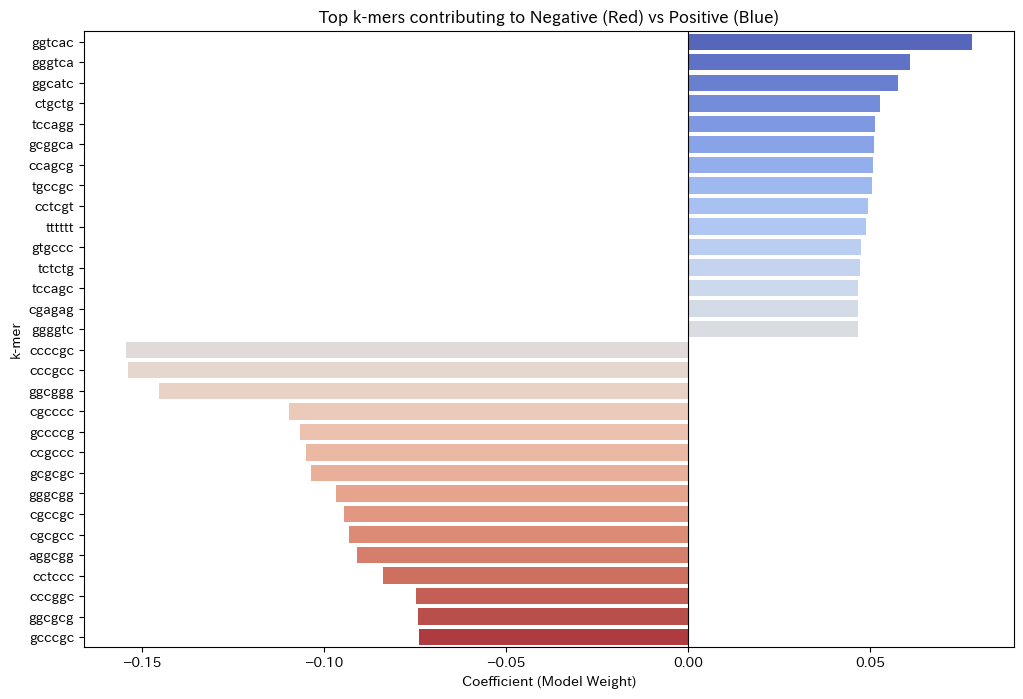

In [ ]:
# -----------------------------------------------------------------------------
# 4. 最終評価結果の可視化 (ROC曲線 & 特徴量)
# -----------------------------------------------------------------------------
print("4. 図表の作成")

# ROC曲線
y_pred_prob = best_model_final.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc:.3f})', color='darkorange', lw=3)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# 特徴量解析
if best_model_name == 'Random Forest':
    importances = best_model_final.feature_importances_
    df_imp = pd.DataFrame({'k-mer': feature_names, 'Score': importances})
    df_imp = df_imp.sort_values('Score', ascending=False).head(20)

    print("\n" + "="*40)
    print(f"Top 20 Important k-mers ({best_model_name})")
    print("="*40)
    print(df_imp.to_string(index=False))
    print("-" * 40)

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Score', y='k-mer', data=df_imp, palette='viridis')
    plt.title(f'Figure 3: Top 20 Important k-mers ({best_model_name})')
    plt.xlabel('Feature Importance')
    plt.show()

else:
    coefs = best_model_final.coef_[0]
    df_coef = pd.DataFrame({'k-mer': feature_names, 'Score': coefs})

    top_pos = df_coef.sort_values('Score', ascending=False).head(15)
    top_neg = df_coef.sort_values('Score', ascending=True).head(15)
    plot_data = pd.concat([top_pos, top_neg])

    print("\n" + "="*60)
    print("Positive Top 15")
    print("="*60)
    print(top_pos.to_string(index=False))

    print("\n" + "="*60)
    print("Negative Top 15")
    print("="*60)
    print(top_neg.to_string(index=False))
    print("-" * 60)

    plt.figure(figsize=(12, 8))
    sns.barplot(data=plot_data, y='k-mer', x='Score', palette='coolwarm')
    plt.title(f'Top k-mers contributing to Negative (Red) vs Positive (Blue)')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.xlabel('Coefficient (Model Weight)')
    plt.show()

In [ ]:
# ==========================================
# 5: 誤分類分析
# ==========================================
print("5. 誤分類分析")

# テストデータに対する予測と確率を取得
y_pred = best_model_final.predict(X_test)
y_prob = best_model_final.predict_proba(X_test)[:, 1]

# 元データの情報を取得
indices = y_test.index
df_error = df_ml.loc[indices].copy()
df_error['True_Label'] = y_test
df_error['Predicted'] = y_pred
df_error['Prob_Positive'] = y_prob

def print_aligned_df(df_in, title):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    print(f"{'Sequence (配列)':<35} | {'Prob (維持確率)':<15} | {'True Label':<10}")
    print("-" * 80)

    for _, row in df_in.iterrows():
        seq = row['Sequence']
        prob = row['Prob_Positive']
        true_lbl = "Maintained" if row['True_Label'] == 1 else "Demethylated"

        print(f"{seq:<35} | {prob:<15.4f} | {true_lbl:<10}")

# -------------------------------------------------------
# 1. False Positive
# -------------------------------------------------------
fp_df = df_error[(df_error['True_Label'] == 0) & (df_error['Predicted'] == 1)]
fp_df = fp_df.sort_values('Prob_Positive', ascending=False).head(20)

print_aligned_df(fp_df, "False Positive")

# -------------------------------------------------------
# 2. False Negative
# -------------------------------------------------------
fn_df = df_error[(df_error['True_Label'] == 1) & (df_error['Predicted'] == 0)]
fn_df = fn_df.sort_values('Prob_Positive', ascending=True).head(20)

print_aligned_df(fn_df, "False Negative")

5. 誤分類分析

False Positive
Sequence (配列)                       | Prob (維持確率)     | True Label
--------------------------------------------------------------------------------
CGCGCGGGATTCCTGTTTTGGCGGCTCAACCGGTCAGTACCCGGACAGTGTTTGCCACAGTGTCTTTGCTTTCTCTATTCTGTCTCACGACAGCGAATTCGGTCCCGGACATTTGTGAAAGTTGGTGGTTTTCATTTTCGCTTCGCTAAGAAGCTAGCAGCAGGAGGAGGAAAGTACGCTACGGTACGGCTGCGTTGACTACCG | 0.8159          | Demethylated
CGCTCCTCCGGCCTCCCTCCAACAGATGGCGCTAGGAAGTCCCGCCTACTGGAAAGGACCCGGATGGGTGGGGTTTCTCGGCTGCGCGCGCAGCTCGCCTCACTCCGCTTGTGCTCTGGGAAGGAGAAGGGCGTGTTTCCGCTTGCTCCTCCGCCATGGCTCGTGGTCCCAAGAAACACCTGAAGCGTGTGGCGGCCCCACGCCACTGGATGCTGGACAAACTGACCGGTGTGTTCGCGCCCCGTCCGTCTGCCGGCCCGCACCGCCTGCGGGAGTGCCTGCCGCTCGCCATCTTCCTGAGGAACAGGCTCAAGTACGCCCTGACCGGCGACGAGGTGAAGAAGATCTGCATGCAGCGGCTCATTAAGGTCGACGGCAAGGTCAGAACCGATGTGGCCTACCCAGCTGGCTTCATGGATGTCATCAGCATCGACAAGAGCGGCGAGAACTTCCGCCTCGTCTACGACACCAAGGGCCGCTTCGCGGTACACCGCATCACGCCCGAGGAGGCCAAGTACAAGCTGTGCAAGGTGAGGAAAGTCTTCGTGGGTACCAAGGGCATCCCGCACCTCGTCACGCACGACGCGCG

In [ ]:
print("6. 誤分類配列のモチーフ含有チェック")

important_pos_motifs = [
    'ggtcac', 'gggtca', 'ggcatc', 'ctgctg', 'tccagg',
    'gcggca', 'ccagcg', 'tgccgc', 'cctcgt', 'tttttt',
    'gtgccc', 'tctctg', 'tccagc', 'cgagag', 'ggggtc'
]

important_neg_motifs = [
    'ccccgc', 'cccgcc', 'ggcggg', 'cgcccc', 'gccccg',
    'ccgccc', 'gcgcgc', 'gggcgg', 'cgccgc', 'cgcgcc',
    'aggcgg', 'cctccc', 'cccggc', 'ggcgcg', 'gcccgc'
]

def analyze_and_print(df_in, title, error_type):
    print("\n" + "="*80)
    print(title)
    print("="*80)

    for i, row in df_in.iterrows():
        seq = row['Sequence'].lower()
        prob = row['Prob_Positive']

        # 1. 配列の中にPositiveモチーフがあるか探す
        found_pos = [m for m in important_pos_motifs if m in seq]

        # 2. 配列の中にNegativeモチーフがあるか探す
        found_neg = [m for m in important_neg_motifs if m in seq]

        # 3. CpGの個数を数える
        cpg_count = seq.count('cg')

        # --- 結果の表示 ---
        print(f"配列ID: {i}")
        print(f"  - 維持確率: {prob:.2%}")
        print(f"  - 含まれていた維持モチーフ: {found_pos}")
        print(f"  - 含まれていた脱メチル化モチーフ: {found_neg}")
        print(f"  - CpGカウント: {cpg_count}個")

        print("-" * 50)

# 実行
analyze_and_print(fp_df.head(1000), "【False Positive】", "FP")
analyze_and_print(fn_df.head(1000), "【False Negative】", "FN")

6. 誤分類配列のモチーフ含有チェック

【False Positive】
配列ID: 585
  - 維持確率: 81.59%
  - 含まれていた維持モチーフ: []
  - 含まれていた脱メチル化モチーフ: []
  - CpGカウント: 17個
--------------------------------------------------
配列ID: 625
  - 維持確率: 71.77%
  - 含まれていた維持モチーフ: ['ggcatc', 'tgccgc', 'cctcgt']
  - 含まれていた脱メチル化モチーフ: ['cccgcc', 'cgcccc', 'gccccg', 'gcgcgc', 'cgcgcc', 'cctccc', 'cccggc', 'gcccgc']
  - CpGカウント: 90個
--------------------------------------------------
配列ID: 421
  - 維持確率: 69.26%
  - 含まれていた維持モチーフ: ['ggcatc', 'tgccgc', 'gtgccc']
  - 含まれていた脱メチル化モチーフ: ['cgccgc', 'cccggc', 'gcccgc']
  - CpGカウント: 21個
--------------------------------------------------
配列ID: 483
  - 維持確率: 69.21%
  - 含まれていた維持モチーフ: ['tctctg']
  - 含まれていた脱メチル化モチーフ: ['ggcggg', 'cgcgcc']
  - CpGカウント: 17個
--------------------------------------------------
配列ID: 659
  - 維持確率: 68.78%
  - 含まれていた維持モチーフ: []
  - 含まれていた脱メチル化モチーフ: []
  - CpGカウント: 15個
--------------------------------------------------
配列ID: 668
  - 維持確率: 64.22%
  - 含まれていた維持モチーフ: ['gggtca', 'ggggtc']
  - 含まれて

In [ ]:
# ==========================================
# 7. 正解データのチェック
# ==========================================
print("7. 正解データの検証")

# 予測結果をまとめる
indices = y_test.index
df_results = df_ml.loc[indices].copy()
df_results['True_Label'] = y_test
df_results['Predicted'] = y_pred
df_results['Prob_Positive'] = y_prob

# -------------------------------------------------------
# 1. True Positiveの抽出
# -------------------------------------------------------
tp_df = df_results[(df_results['True_Label'] == 1) & (df_results['Predicted'] == 1)]
tp_df = tp_df.sort_values('Prob_Positive', ascending=False).head(100)

# -------------------------------------------------------
# 2. True Negativeの抽出
# -------------------------------------------------------
tn_df = df_results[(df_results['True_Label'] == 0) & (df_results['Predicted'] == 0)]
tn_df = tn_df.sort_values('Prob_Positive', ascending=True).head(100)

def analyze_and_print_v2(df_in, title):
    print("\n" + "="*80)
    print(title)
    print("="*80)
    for i, row in df_in.iterrows():
        seq = row['Sequence'].lower()
        prob = row['Prob_Positive']
        found_pos = [m for m in important_pos_motifs if m in seq]
        found_neg = [m for m in important_neg_motifs if m in seq]
        cpg_count = seq.count('cg')

        print(f"配列ID: {i}")
        print(f"  - 維持確率: {prob:.2%}")
        print(f"  - 維持モチーフ: {found_pos}")
        print(f"  - 脱メチル化モチーフ: {found_neg}")
        print(f"  - CpGカウント: {cpg_count}個")

analyze_and_print_v2(tp_df, "【True Positive Ranking】")
analyze_and_print_v2(tn_df, "【True Negative Ranking】")

7. 正解データの検証

【True Positive Ranking】
配列ID: 54
  - 維持確率: 99.56%
  - 維持モチーフ: ['gcggca']
  - 脱メチル化モチーフ: []
  - CpGカウント: 30個
配列ID: 148
  - 維持確率: 98.74%
  - 維持モチーフ: []
  - 脱メチル化モチーフ: []
  - CpGカウント: 29個
配列ID: 355
  - 維持確率: 97.98%
  - 維持モチーフ: ['ggtcac', 'gggtca']
  - 脱メチル化モチーフ: ['gggcgg']
  - CpGカウント: 52個
配列ID: 90
  - 維持確率: 96.40%
  - 維持モチーフ: ['ctgctg', 'gcggca', 'ccagcg', 'tgccgc', 'cctcgt']
  - 脱メチル化モチーフ: []
  - CpGカウント: 37個
配列ID: 2
  - 維持確率: 96.12%
  - 維持モチーフ: []
  - 脱メチル化モチーフ: []
  - CpGカウント: 52個
配列ID: 81
  - 維持確率: 96.08%
  - 維持モチーフ: ['ctgctg', 'tccagg', 'gcggca', 'ccagcg', 'tgccgc', 'tttttt', 'cgagag', 'ggggtc']
  - 脱メチル化モチーフ: ['cgcccc', 'gccccg', 'ccgccc', 'cgccgc', 'aggcgg']
  - CpGカウント: 53個
配列ID: 311
  - 維持確率: 95.90%
  - 維持モチーフ: ['cctcgt']
  - 脱メチル化モチーフ: []
  - CpGカウント: 21個
配列ID: 132
  - 維持確率: 95.40%
  - 維持モチーフ: []
  - 脱メチル化モチーフ: []
  - CpGカウント: 18個
配列ID: 18
  - 維持確率: 94.49%
  - 維持モチーフ: ['ggtcac', 'ggcatc', 'ctgctg', 'tgccgc', 'cctcgt', 'tttttt', 'cgagag']
  - 脱メチル化モチーフ: ['cgcccc', '

8. 統計検定結果 (T-test & Mann-Whitney U)
Comparison Pair                          | Metric          | Mean A vs B     | T-test p     | U-test p    
--------------------------------------------------------------------------------------------------------------
TP vs TN
                                         | pos_count       | 2.0 vs 2.9   | 0.03137 *   | 0.01336 *  
                                         | neg_count       | 1.9 vs 8.6   | 0.00000 *** | 0.00000 ***
                                         | cpg_count       | 27.9 vs 49.3   | 0.00062 *** | 0.00000 ***
--------------------------------------------------------------------------------------------------------------
TP vs FP
                                         | pos_count       | 2.0 vs 1.9   | 0.86962     | 0.89176    
                                         | neg_count       | 1.9 vs 3.7   | 0.02174 *   | 0.00711 ** 
                                         | cpg_count       | 27.9 vs 30.0   | 0.69347     | 0.74904    
-

/tmp/ipython-input-1720678837.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=metric, data=combined_df, ax=axes[i], palette='Set2')
/tmp/ipython-input-1720678837.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=metric, data=combined_df, ax=axes[i], palette='Set2')
/tmp/ipython-input-1720678837.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Group', y=metric, data=combined_df, ax=axes[i], palette='Set2')


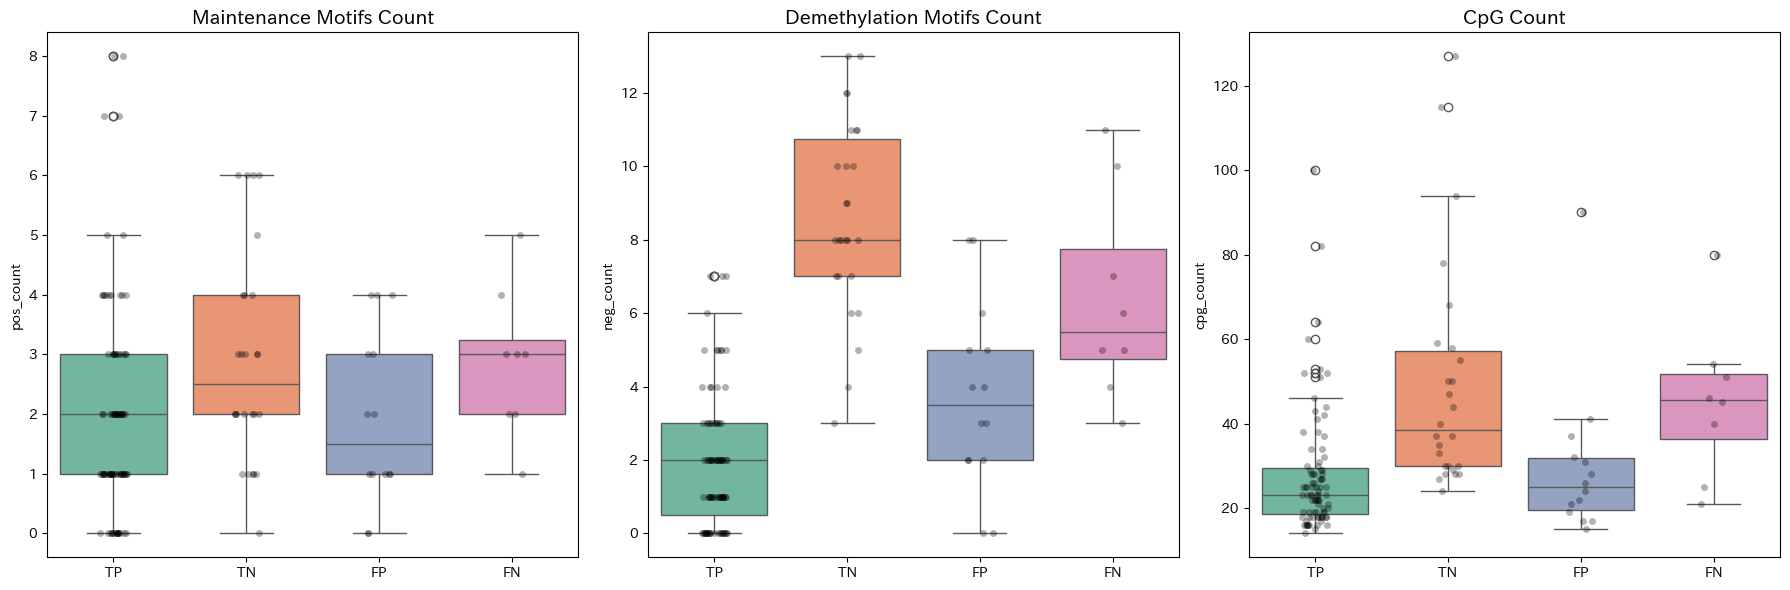

In [ ]:
# ---------------------------------------------------------
# 1. データの前準備（モチーフ数とCpG数を列として追加）
# ---------------------------------------------------------
# 分析対象のモチーフリスト
important_pos_motifs = [
    'ggtcac', 'gggtca', 'ggcatc', 'ctgctg', 'tccagg',
    'gcggca', 'ccagcg', 'tgccgc', 'cctcgt', 'tttttt',
    'gtgccc', 'tctctg', 'tccagc', 'cgagag', 'ggggtc'
]
important_neg_motifs = [
    'ccccgc', 'cccgcc', 'ggcggg', 'cgcccc', 'gccccg',
    'ccgccc', 'gcgcgc', 'gggcgg', 'cgccgc', 'cgcgcc',
    'aggcgg', 'cctccc', 'cccggc', 'ggcgcg', 'gcccgc'
]

def add_features(df):
    df = df.copy()
    df['pos_count'] = df['Sequence'].str.lower().apply(lambda x: sum(1 for m in important_pos_motifs if m in x))
    df['neg_count'] = df['Sequence'].str.lower().apply(lambda x: sum(1 for m in important_neg_motifs if m in x))
    df['cpg_count'] = df['Sequence'].str.lower().apply(lambda x: x.count('cg'))
    return df

df_tp_stats = add_features(tp_df)
df_tn_stats = add_features(tn_df)
df_fp_stats = add_features(fp_df)
df_fn_stats = add_features(fn_df)

groups = {
    'TP': df_tp_stats,
    'TN': df_tn_stats,
    'FP': df_fp_stats,
    'FN': df_fn_stats
}

# ---------------------------------------------------------
# 2. すべてのペアで検定を実行
# ---------------------------------------------------------
print("8. 統計検定結果 (T-test & Mann-Whitney U)")
print(f"{'Comparison Pair':<40} | {'Metric':<15} | {'Mean A vs B':<15} | {'T-test p':<12} | {'U-test p':<12}")
print("-" * 110)

metrics = ['pos_count', 'neg_count', 'cpg_count']

for (name1, df1), (name2, df2) in combinations(groups.items(), 2):
    print(f"{name1} vs {name2}")

    for metric in metrics:
        data1 = df1[metric]
        data2 = df2[metric]

        # 平均値
        mean1 = data1.mean()
        mean2 = data2.mean()

        # 1. Welch's T-test
        t_stat, p_t = stats.ttest_ind(data1, data2, equal_var=False)

        # 2. Mann-Whitney U test
        u_stat, p_u = stats.mannwhitneyu(data1, data2, alternative='two-sided')

        # 有意水準のマーク設定
        sig_t = "***" if p_t < 0.001 else "**" if p_t < 0.01 else "*" if p_t < 0.05 else ""
        sig_u = "***" if p_u < 0.001 else "**" if p_u < 0.01 else "*" if p_u < 0.05 else ""

        print(f"{'':<40} | {metric:<15} | {mean1:.1f} vs {mean2:.1f}   | {p_t:.5f} {sig_t:<3} | {p_u:.5f} {sig_u:<3}")
    print("-" * 110)

# ---------------------------------------------------------
# 3. 箱ひげ図で可視化
# ---------------------------------------------------------
combined_df = pd.concat([
    df_tp_stats.assign(Group='TP'),
    df_tn_stats.assign(Group='TN'),
    df_fp_stats.assign(Group='FP'),
    df_fn_stats.assign(Group='FN')
])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = {
    'pos_count': 'Maintenance Motifs Count',
    'neg_count': 'Demethylation Motifs Count',
    'cpg_count': 'CpG Count'
}

for i, metric in enumerate(metrics):
    sns.boxplot(x='Group', y=metric, data=combined_df, ax=axes[i], palette='Set2')
    sns.stripplot(x='Group', y=metric, data=combined_df, ax=axes[i], color='black', alpha=0.3, jitter=True)
    axes[i].set_title(titles[metric], fontsize=14)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

#環境検索

In [ ]:
import platform
import pandas as pd
import sklearn
import matplotlib
import seaborn

print("【環境情報】")
print(f"Python version: {platform.python_version()}")
print("-" * 20)
print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")

【環境情報】
Python version: 3.12.12
--------------------
pandas version: 2.2.2
scikit-learn version: 1.6.1
matplotlib version: 3.10.0
seaborn version: 0.13.2
